In [2]:
!python --version

Python 3.13.7


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import networkx as nx
import torch
from torch.nn import Conv2d
from torch.nn.utils import parameters_to_vector

In [4]:
with open(r"../root.jpeg", mode="rb") as fp:
    root = np.array(Image.open(fp), dtype=np.uint8)

In [24]:
image_h, image_w, _ = np.array(root.shape) // 300

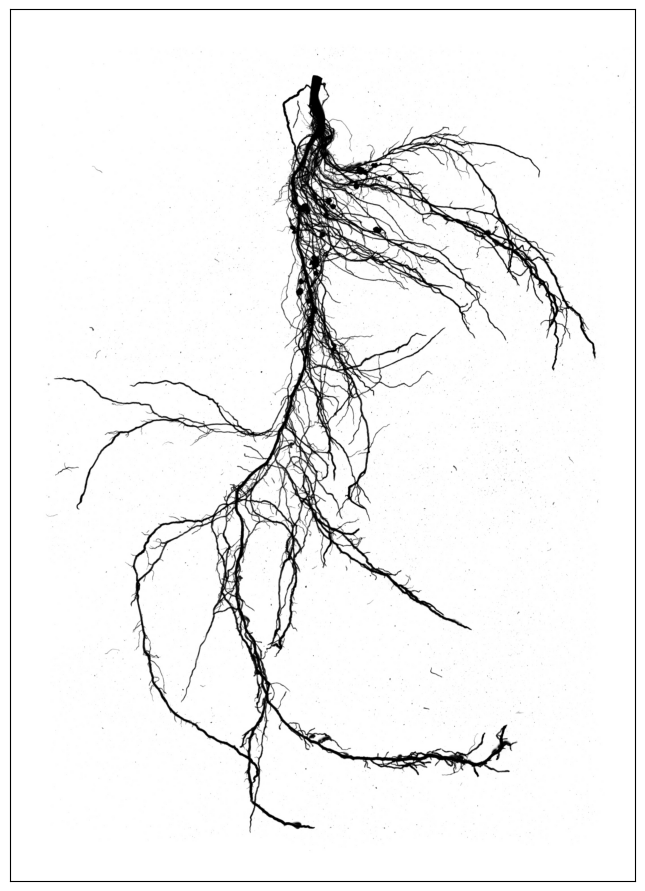

In [25]:
fig, axes = plt.subplots()
fig.set_size_inches(image_w, image_h)
axes.imshow(root)
plt.tight_layout()
axes.set_xticks([])
axes.set_yticks([])
plt.show()

In [34]:
root_tensor = torch.FloatTensor(np.array(np.unstack(root, axis=2)) / 255.0)
root_tensor.shape

torch.Size([3, 3078, 2207])

In [39]:
with torch.no_grad():
    convolutions = Conv2d(in_channels=3, out_channels=9, kernel_size=(4, 4), stride=(1, 1))(root_tensor)

In [41]:
convolutions.shape

torch.Size([9, 3075, 2204])

In [10]:
with open(file=r"\\ad.uws.edu.au\dfshare\HomesBNK$\90963425\Downloads\sam_vit_h_4b8939.pth", mode="rb") as fp:
    params_sam = torch.load(f=fp, map_location="cpu", weights_only=False)

In [12]:
for (layer, param) in params_sam.items():
    print(f"{layer} => {torch.numel(param)}")

image_encoder.neck.0.weight => 327680
image_encoder.neck.1.weight => 256
image_encoder.neck.1.bias => 256
image_encoder.neck.2.weight => 589824
image_encoder.neck.3.weight => 256
image_encoder.neck.3.bias => 256
image_encoder.patch_embed.proj.weight => 983040
image_encoder.patch_embed.proj.bias => 1280
image_encoder.blocks.0.norm1.weight => 1280
image_encoder.blocks.0.norm1.bias => 1280
image_encoder.blocks.0.attn.rel_pos_h => 2160
image_encoder.blocks.0.attn.rel_pos_w => 2160
image_encoder.blocks.0.attn.qkv.weight => 4915200
image_encoder.blocks.0.attn.qkv.bias => 3840
image_encoder.blocks.0.attn.proj.weight => 1638400
image_encoder.blocks.0.attn.proj.bias => 1280
image_encoder.blocks.0.norm2.weight => 1280
image_encoder.blocks.0.norm2.bias => 1280
image_encoder.blocks.0.mlp.lin1.weight => 6553600
image_encoder.blocks.0.mlp.lin1.bias => 5120
image_encoder.blocks.0.mlp.lin2.weight => 6553600
image_encoder.blocks.0.mlp.lin2.bias => 1280
image_encoder.blocks.1.norm1.weight => 1280
image_

In [14]:
sam_n_params = np.array(list(map(torch.numel, params_sam.values())))

In [17]:
sam_n_params.sum() / 1e6

np.float64(641.090864)

In [20]:
params_sam.get("model_state", 0)

0

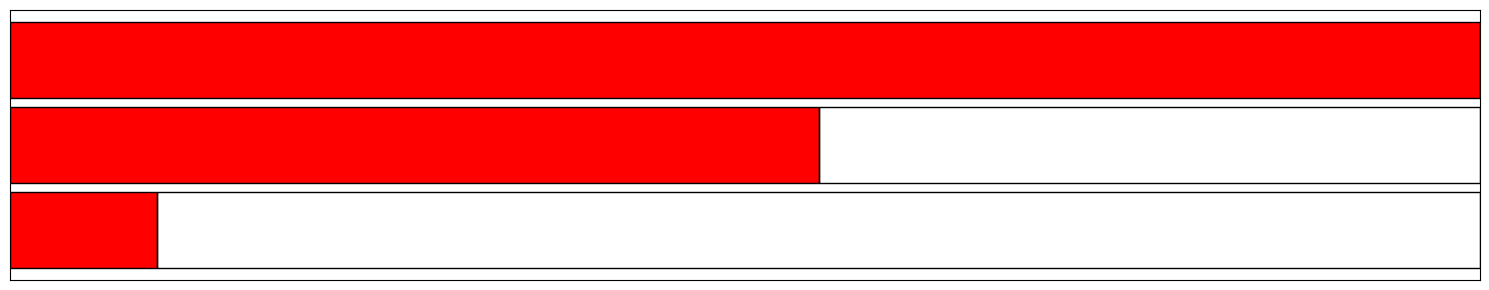

In [19]:
start = np.linspace(10, 100, 3)
fig, axes = plt.subplots()
fig.set_size_inches(15, 3)
axes.barh(y=range(3), width=start, height=0.90, color="red", edgecolor="black")
axes.barh(y=range(3), width=100-start, left=start, height=0.90, color="none", edgecolor="black")
axes.set_xticks([])
axes.set_yticks([])
plt.tight_layout()
# plt.show()
plt.savefig(r"../plots/indic.png", format="png", dpi=300)

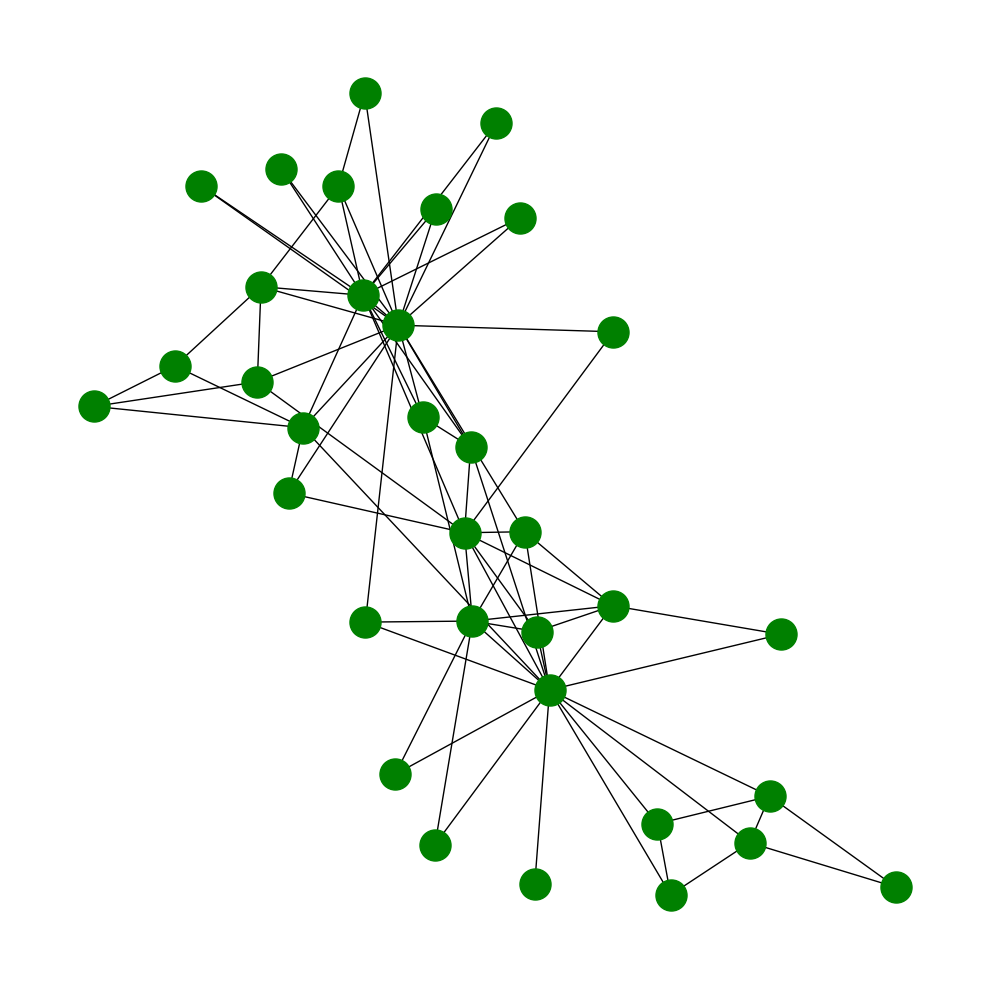

In [54]:
karate = nx.karate_club_graph()
fig, axes = plt.subplots()
fig.set_size_inches(10, 10)

for c in ("red", "blue", "green"):
    axes.clear()
    nx.draw(karate, ax=axes, edge_color="black", node_color=c, node_size=500)
    plt.tight_layout()
    plt.savefig(fname=f"../plots/karate_{c}.png", format="png", dpi=400, transparent=True)

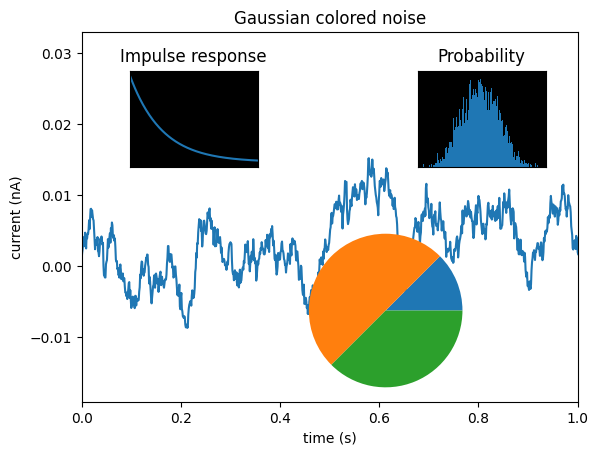

In [61]:
np.random.seed(19680801)  # Fixing random state for reproducibility.

# create some data to use for the plot
dt = 0.001
t = np.arange(0.0, 10.0, dt)
r = np.exp(-t[:1000] / 0.05)  # impulse response
x = np.random.randn(len(t))
s = np.convolve(x, r)[:len(x)] * dt  # colored noise

fig, main_ax = plt.subplots()
main_ax.plot(t, s)
main_ax.set_xlim(0, 1)
main_ax.set_ylim(1.1 * np.min(s), 2 * np.max(s))
main_ax.set_xlabel('time (s)')
main_ax.set_ylabel('current (nA)')
main_ax.set_title('Gaussian colored noise')

# this is an inset Axes over the main Axes
right_inset_ax = fig.add_axes([.65, .6, .2, .2], facecolor='k')
right_inset_ax.hist(s, 400, density=True)
right_inset_ax.set(title='Probability', xticks=[], yticks=[])

# this is another inset Axes over the main Axes
left_inset_ax = fig.add_axes([.2, .6, .2, .2], facecolor='k')
left_inset_ax.plot(t[:len(r)], r)
left_inset_ax.set(title='Impulse response', xlim=(0, .2), xticks=[], yticks=[])

ax = fig.add_axes([0.4, 0.1, .4, .4]) # tuple (left, bottom, width, height)
ax.pie(x=(12.5, 50, 37.5), startangle=0)

plt.show()

In [35]:
image = np.array(Image.open(r"../The-Role-of-Oxygen-in-Photosynthesis.jpg"))
image.shape

(630, 1200, 3)

In [36]:
image[:, :600] =  image[:, 600:] * 0.65

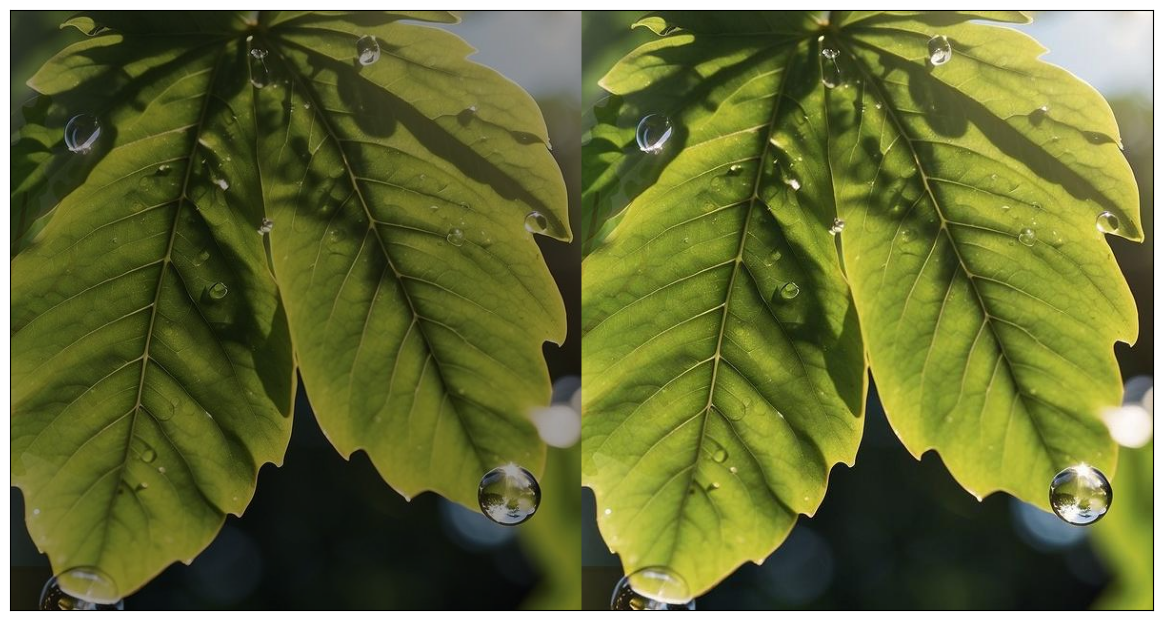

In [39]:
fig, axes = plt.subplots()
fig.set_size_inches(12, 6.3)
axes.imshow(image)
axes.set_xticks([])
axes.set_yticks([])
# plt.show()
plt.tight_layout()
plt.savefig(r"../shade.png", dpi=400)